Dataset Loaded Successfully
   age  income  expenses  savings   debt risk_tolerance  savings_rate  \
0   50   74813     88822    66610  11989            Low      0.890353   
1   36   67198     20901     6401  13780           High      0.095256   
2   29   38820     46552    20193   6589         Medium      0.520170   
3   42   54070     46055    49864  34812            Low      0.922212   
4   40   99768     52685    25307  28128         Medium      0.253658   

   expense_ratio  debt_ratio financial_segment  
0       1.187254    0.160253        High Saver  
1       0.311036    0.205066         Low Saver  
2       1.199176    0.169732        High Saver  
3       0.851766    0.643832        High Saver  
4       0.528075    0.281934      Medium Saver  

Encoded Dataset Preview
   age  income  expenses  savings   debt risk_tolerance  savings_rate  \
0   50   74813     88822    66610  11989            Low      0.890353   
1   36   67198     20901     6401  13780           High      0.09525

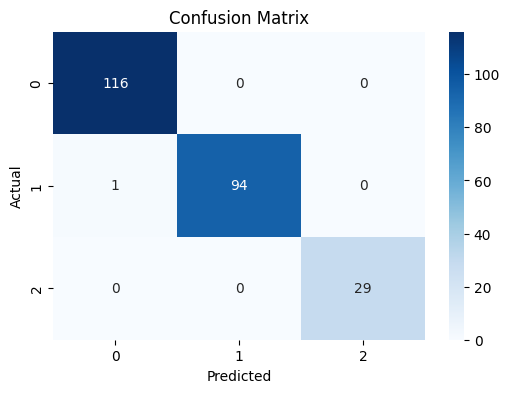


Feature Importance:
         feature  importance
2        savings    0.649660
4   savings_rate    0.263660
0         income    0.034646
5  expense_ratio    0.016728
6     debt_ratio    0.016234
3           debt    0.009647
1       expenses    0.009426


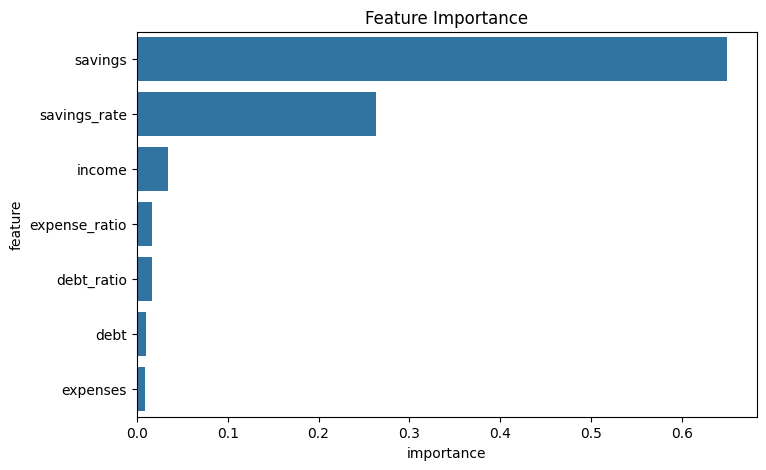


Model saved to models/risk_model.pkl

Cluster Counts:
cluster
0    421
1    404
2    375
Name: count, dtype: int64


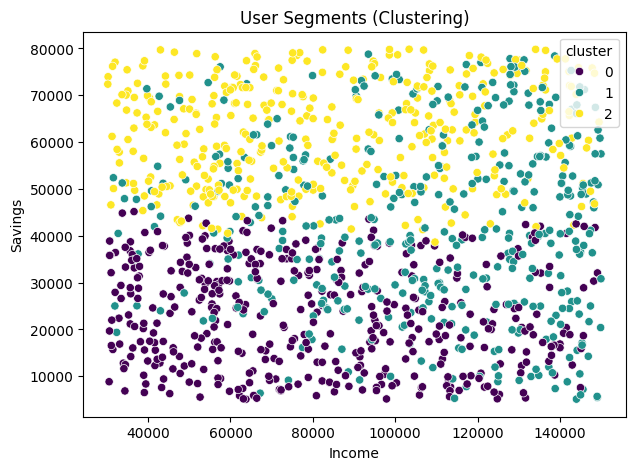


Cluster Summary:
                income      expenses       savings          debt
cluster                                                         
0         80564.218527  61164.472684  23019.011876  29112.482185
1        106972.301980  32353.051980  42274.834158  19807.601485
2         84003.736000  62517.018667  62114.066667  26482.885333

Example Portfolio Allocation for Medium Risk:
{'Stocks': 40, 'ETFs': 30, 'Bonds': 20, 'Cash': 10}


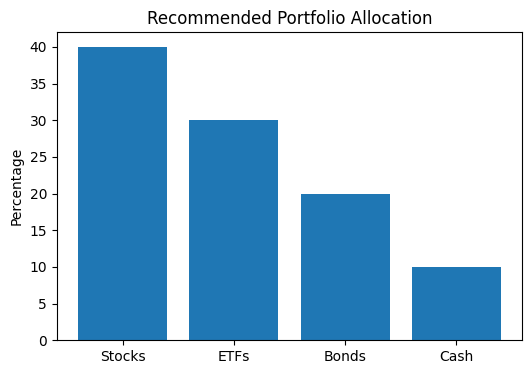


Final dataset with clusters saved.


In [3]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------
# LOAD DATASET
# ---------------------------------------------------

df = pd.read_csv("../data/processed_financial_data.csv")

print("Dataset Loaded Successfully")
print(df.head())


# ---------------------------------------------------
# ENCODE TARGET VARIABLE
# ---------------------------------------------------

mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["risk_encoded"] = df["risk_tolerance"].map(mapping)

print("\nEncoded Dataset Preview")
print(df.head())


# ---------------------------------------------------
# SELECT FEATURES
# ---------------------------------------------------

features = [
    "income",
    "expenses",
    "savings",
    "debt",
    "savings_rate",
    "expense_ratio",
    "debt_ratio"
]

X = df[features]
y = df["risk_encoded"]


# ---------------------------------------------------
# TRAIN TEST SPLIT
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ---------------------------------------------------
# TRAIN MACHINE LEARNING MODEL
# ---------------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Complete")


# ---------------------------------------------------
# MODEL PREDICTIONS
# ---------------------------------------------------

predictions = model.predict(X_test)


# ---------------------------------------------------
# MODEL EVALUATION
# ---------------------------------------------------

print("\nClassification Report:")
print(classification_report(y_test, predictions))


# ---------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ---------------------------------------------------
# FEATURE IMPORTANCE
# ---------------------------------------------------

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(8,5))

sns.barplot(
    x="importance",
    y="feature",
    data=importance_df
)

plt.title("Feature Importance")

plt.show()


# ---------------------------------------------------
# SAVE MODEL
# ---------------------------------------------------

joblib.dump(model, "../models/risk_model.pkl")

print("\nModel saved to models/risk_model.pkl")


# ---------------------------------------------------
# USER SEGMENTATION USING CLUSTERING
# ---------------------------------------------------

cluster_features = df[
    [
        "income",
        "expenses",
        "savings",
        "debt"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_features)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(scaled_features)

print("\nCluster Counts:")
print(df["cluster"].value_counts())


# ---------------------------------------------------
# CLUSTER VISUALIZATION
# ---------------------------------------------------

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["income"],
    y=df["savings"],
    hue=df["cluster"],
    palette="viridis"
)

plt.title("User Segments (Clustering)")
plt.xlabel("Income")
plt.ylabel("Savings")

plt.show()


# ---------------------------------------------------
# CLUSTER INSIGHTS
# ---------------------------------------------------

cluster_summary = df.groupby("cluster")[
    [
        "income",
        "expenses",
        "savings",
        "debt"
    ]
].mean()

print("\nCluster Summary:")
print(cluster_summary)


# ---------------------------------------------------
# PORTFOLIO ALLOCATION LOGIC
# ---------------------------------------------------

def portfolio_allocation(risk_level):

    if risk_level == "High":
        return {
            "Stocks": 60,
            "ETFs": 20,
            "Bonds": 10,
            "Cash": 10
        }

    elif risk_level == "Medium":
        return {
            "Stocks": 40,
            "ETFs": 30,
            "Bonds": 20,
            "Cash": 10
        }

    else:
        return {
            "Stocks": 20,
            "ETFs": 20,
            "Bonds": 40,
            "Cash": 20
        }


# ---------------------------------------------------
# EXAMPLE PORTFOLIO
# ---------------------------------------------------

example_risk = "Medium"

portfolio = portfolio_allocation(example_risk)

print("\nExample Portfolio Allocation for Medium Risk:")
print(portfolio)


# ---------------------------------------------------
# PORTFOLIO VISUALIZATION
# ---------------------------------------------------

assets = list(portfolio.keys())
values = list(portfolio.values())

plt.figure(figsize=(6,4))

plt.bar(assets, values)

plt.title("Recommended Portfolio Allocation")
plt.ylabel("Percentage")

plt.show()


# ---------------------------------------------------
# SAVE FINAL DATASET
# ---------------------------------------------------

df.to_csv("../data/final_financial_dataset.csv", index=False)

print("\nFinal dataset with clusters saved.")